In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sci

In [2]:
eug = pd.read_csv("cleaned_eug.csv")                        # | Read in new, cleaned data |
spd = pd.read_csv("cleaned_spd.csv")                        # | Read in new, cleaned data |

#### Difference in Differences plot

In [3]:
eug['calltime'] = pd.to_datetime(eug['calltime'])           # | Convert calltime into datetime again |
spd['calltime'] = pd.to_datetime(spd['calltime'])           # | Convert calltime into datetime again |

In [4]:
treatment_date = pd.to_datetime('2025-04-07')  # | Date when CAHOOTS was de-funded |

eug_counts = eug.groupby(eug['calltime'].dt.floor('D')).size().rolling(7).mean().reset_index().rename(columns = {0: "count"})       # | Get total number of call by week |                   
spd_counts = spd.groupby(spd['calltime'].dt.floor('D')).size().rolling(7).mean().reset_index().rename(columns = {0: "count"})       # | Get total number of call by week |  
merged = pd.merge(eug_counts, spd_counts, on='calltime').rename(columns={"count_x":"count_eug", "count_y":"count_spd"})             # | Merge these datasets together for easy plotting |  
merged

,calltime,count_eug,count_spd
0,2015-01-01,NaN,NaN
1,2015-01-02,NaN,NaN
2,2015-01-03,NaN,NaN
3,2015-01-04,NaN,NaN
4,2015-01-05,NaN,NaN
...,...,...,...
4000,2025-12-26,14.428571,5.571429
4001,2025-12-27,14.571429,5.428571
4002,2025-12-28,13.857143,5.142857
4003,2025-12-29,14.857143,4.857143


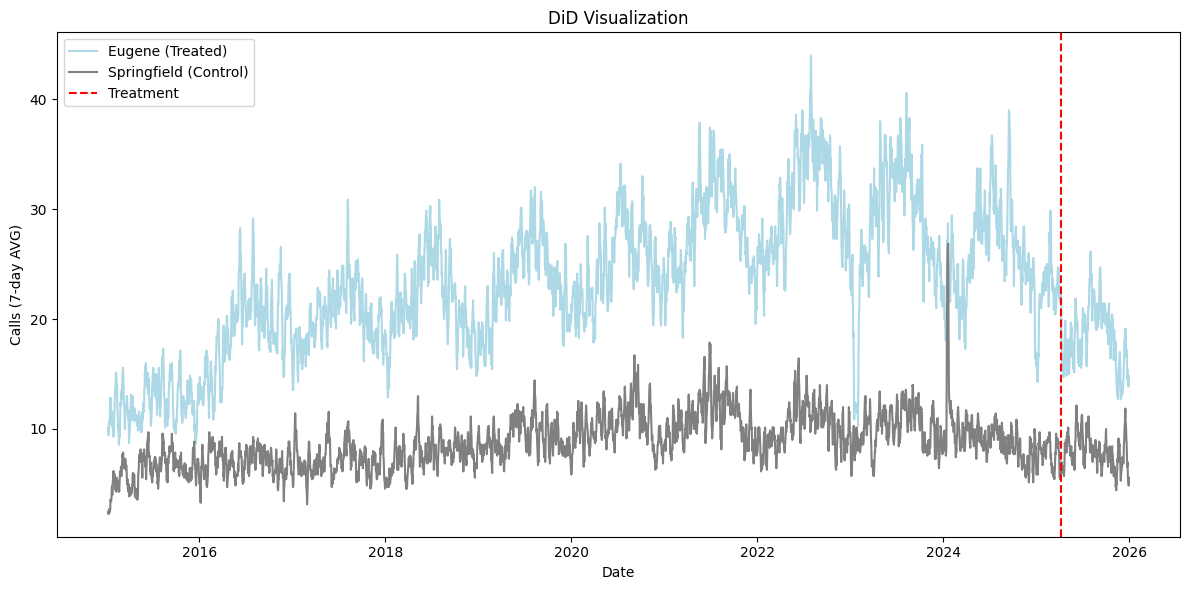

In [5]:
plt.figure(figsize=(12,6))
plt.plot(merged['calltime'], merged['count_eug'], label='Eugene (Treated)', color='lightblue')
plt.plot(merged['calltime'], merged['count_spd'], label='Springfield (Control)', color='gray')

plt.axvline(treatment_date, linestyle='--', color='black', c="red", label="Treatment")

plt.legend()
plt.title('DiD Visualization')
plt.ylabel('Calls (7-day AVG)'), plt.xlabel("Date")
plt.tight_layout()
plt.savefig("diff_in_diff.png", dpi=300)
plt.show()

#### Conduct T-Test

In [6]:
before_treatment = merged[merged["calltime"] < treatment_date]["count_eug"]
after_treatment = merged[merged["calltime"] > treatment_date]["count_eug"]

# Perform test
t_val, p = sci.ttest_ind(before_treatment, after_treatment, equal_var=False, nan_policy='omit')               # | Independent Two-Sample T-Test since sizes of before + after not same |
                                                                                                              # | equal_var=False since variances are NOT the same                     |
print(f"P-value: {p}")                                                                                        # | nan_policy="omit" since some observations are missing/nan            |


P-value: 3.9940943925041096e-95


In [7]:
if p < 0.05:
    print("We reject the null hypothesis that the mean of the number of welfare check calls is the same after treatment.")
else: 
    print("We fail to reject the null hypothesis that the mean of the number of welfare check calls is the same after treatment.") 


We reject the null hypothesis that the mean of the number of welfare check calls is the same after treatment.
